# 🌍 mBERT Fine-Tuning for Disaster Response Classification

**Model:** `bert-base-multilingual-cased` (mBERT)  
**Task:** 5-class classification of disaster-related social media messages  
**Dataset:** HumAID (~74K annotated tweets)  

### Classes
| Class | Description |
|---|---|
| Critical Rescue | People displaced, injured, dead, or missing |
| Resource Requests | Requests for food, water, shelter, medical supplies |
| Volunteering and Donations | Offers of help, donation drives |
| Situational Awareness | Infrastructure damage, weather updates |
| Irrelevant | Sympathy messages, unrelated content |

---

### ⚡ Instructions
1. Go to **Runtime → Change runtime type → T4 GPU** (or any available GPU)
2. Upload `humaid_processed.csv` when prompted
3. Run all cells in order
4. Download the trained model and results at the end

## 0. Setup — Install Dependencies & Check GPU

In [ ]:
# Install required packages (Colab has torch pre-installed)
!pip install -q transformers datasets accelerate scikit-learn matplotlib seaborn

In [ ]:
import torch
import os

# Verify GPU is available
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.10.0+cu128
CUDA available: True


## 1. Upload & Load Dataset

You have **two options** to load the dataset:

- **Option A:** Upload `humaid_processed.csv` manually using the file upload widget
- **Option B:** Mount Google Drive and provide the path

Uncomment the option you want to use below.

In [ ]:
# =============================================
# OPTION A: Upload file directly
# =============================================
# from google.colab import files
# uploaded = files.upload()  # This opens a file picker — select humaid_processed.csv
# DATA_PATH = "humaid_processed.csv"

# =============================================
# OPTION B: Mount Google Drive (if file is in Drive)
# =============================================
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/NLP_PROJECT/humaid_processed.csv"  # ← Update this path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(DATA_PATH)
print(f"Total samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSplit distribution:")
print(df['split'].value_counts())
print(f"\nLabel distribution:")
print(df['target_label'].value_counts())
df.head()

Total samples: 74227

Columns: ['tweet_id', 'tweet_text', 'class_label', 'event', 'split', 'event_set', 'target_label', 'clean_text', 'text_length', 'word_count']

Split distribution:
split
train    51952
test     14711
dev       7564
Name: count, dtype: int64

Label distribution:
target_label
Situational Awareness         33691
Volunteering and Donations    20849
Critical Rescue               10949
Irrelevant                     6145
Resource Requests              2593
Name: count, dtype: int64


,tweet_id,tweet_text,class_label,event,split,event_set,target_label,clean_text,text_length,word_count
0,735891446960623616,RT @DonBradshawNTV: How @MarshallAmpsUK came t...,other_relevant_information,canada_wildfires_2016,train,set1,Situational Awareness,how came to the assistance of fort mcmurray wi...,79,15
1,731202020296818688,Red Cross distributes $30M to Fort McMurray wi...,displaced_people_and_evacuations,canada_wildfires_2016,train,set1,Critical Rescue,red cross distributes 30m to fort mcmurray wil...,69,12
2,733665357236342784,Interesting insights on the shifting communica...,other_relevant_information,canada_wildfires_2016,train,set1,Situational Awareness,interesting insights on the shifting communica...,110,15
3,731963038429929472,RT @globeandmail: Oil sands producers helping ...,rescue_volunteering_or_donation_effort,canada_wildfires_2016,train,set1,Volunteering and Donations,oil sands producers helping workers affected b...,75,11
4,728674838034944001,Ottawa to match Red Cross donations for Fort M...,rescue_volunteering_or_donation_effort,canada_wildfires_2016,train,set1,Volunteering and Donations,ottawa to match red cross donations for fort m...,76,12


## 2. Configuration

In [ ]:
from transformers import set_seed

set_seed(42)

# === Model Configuration ===
MODEL_NAME = "bert-base-multilingual-cased"   # Downloads directly from HuggingFace
MAX_LENGTH = 128
BATCH_SIZE = 32          # Works well on T4 (16GB). Reduce to 16 if OOM.
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
WEIGHT_DECAY = 0.01

# === Label Setup ===
LABEL_NAMES = [
    'Situational Awareness',
    'Critical Rescue',
    'Volunteering and Donations',
    'Irrelevant',
    'Resource Requests'
]
label2id = {label: i for i, label in enumerate(LABEL_NAMES)}
id2label = {i: label for i, label in enumerate(LABEL_NAMES)}

# === Output Directories ===
OUTPUT_DIR = "/content/results_mbert"
FINAL_MODEL_DIR = "/content/model_mbert"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

print("Configuration set!")
print(f"  Model: {MODEL_NAME}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max length: {MAX_LENGTH}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Labels: {LABEL_NAMES}")

Configuration set!
  Model: bert-base-multilingual-cased
  Batch size: 32
  Max length: 128
  Epochs: 3
  Labels: ['Situational Awareness', 'Critical Rescue', 'Volunteering and Donations', 'Irrelevant', 'Resource Requests']


## 3. Prepare Data Splits

In [ ]:
from datasets import Dataset

# Map labels to integers
df['label'] = df['target_label'].map(label2id)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Split into train / dev / test
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'dev'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Convert to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df[['clean_text', 'label']])
val_dataset   = Dataset.from_pandas(val_df[['clean_text', 'label']])
test_dataset  = Dataset.from_pandas(test_df[['clean_text', 'label']])

Train: 51952 | Val: 7564 | Test: 14711


## 4. Tokenization

In [ ]:
from transformers import AutoTokenizer, DataCollatorWithPadding

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    """Tokenize text with truncation and padding to max_length."""
    texts = [str(x) if x is not None else "" for x in examples["clean_text"]]
    return tokenizer(texts, truncation=True, padding="max_length", max_length=MAX_LENGTH)

print("Tokenizing train set...")
tokenized_train = train_dataset.map(tokenize_function, batched=True, batch_size=1000)
print("Tokenizing validation set...")
tokenized_val = val_dataset.map(tokenize_function, batched=True, batch_size=1000)
print("Tokenizing test set...")
tokenized_test = test_dataset.map(tokenize_function, batched=True, batch_size=1000)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"\nTokenization complete!")
print(f"  Train features: {tokenized_train.features}")
print(f"  Sample token count: {len(tokenized_train[0]['input_ids'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Tokenizing validation set...


Map:   0%|          | 0/7564 [00:00<?, ? examples/s]

Tokenizing test set...


Map:   0%|          | 0/14711 [00:00<?, ? examples/s]


Tokenization complete!
  Train features: {'clean_text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
  Sample token count: 128


## 5. Load Model

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_NAMES),
    id2label=id2label,
    label2id=label2id
)

# Print model size
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
# print(f"Model size: ~{total_params * 4 / 1e6:.0f} MB (FP32)")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 177,857,285
Trainable parameters: 177,857,285
Model size: ~711 MB (FP32)


## 6. Define Metrics

In [ ]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    classification_report,
    confusion_matrix
)

def compute_metrics(pred):
    """Compute accuracy, F1, precision, and recall (weighted average)."""
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("Metrics function defined.")

Metrics function defined.


## 7. Training 🚀

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,  # Larger batch for eval (no gradients)
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir='./logs_mbert',
    logging_steps=50,
    fp16=True,                   # Mixed precision for faster training on T4/V100
    report_to="none",            # Disable wandb/tensorboard
    dataloader_num_workers=2,    # Colab can handle 2 workers
    save_total_limit=2,          # Keep only the 2 best checkpoints to save disk space
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(f"Training steps per epoch: {len(tokenized_train) // BATCH_SIZE}")
print(f"Total training steps: {(len(tokenized_train) // BATCH_SIZE) * NUM_EPOCHS}")
print("\n🚀 Starting mBERT training...")
train_result = trainer.train()

print("\n✅ Training complete!")
print(f"  Training loss: {train_result.training_loss:.4f}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training steps per epoch: 1623
Total training steps: 4869

🚀 Starting mBERT training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.460208,0.442012,0.831174,0.824480,0.826067,0.831174
2,0.402021,0.442565,0.832628,0.823693,0.829348,0.832628
3,0.275613,0.444193,0.836991,0.834857,0.834057,0.836991


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Training complete!
  Training loss: 0.4046


## 8. Evaluation on Test Set

In [ ]:
# Evaluate on test set
print("Evaluating on test set...")
test_results = trainer.evaluate(tokenized_test)
print("\n📊 Test Set Results:")
for key, value in test_results.items():
    if key.startswith('eval_'):
        print(f"  {key.replace('eval_', '')}: {value:.4f}")

Evaluating on test set...



📊 Test Set Results:
  loss: 0.4373
  accuracy: 0.8428
  f1: 0.8402
  precision: 0.8394
  recall: 0.8428
  runtime: 23.3285
  samples_per_second: 630.6030
  steps_per_second: 9.8590


In [ ]:
# Get predictions for detailed classification report
predictions = trainer.predict(tokenized_test)
y_pred = predictions.predictions.argmax(-1)
y_true = predictions.label_ids

# Full classification report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
report = classification_report(
    y_true, y_pred,
    target_names=LABEL_NAMES,
    digits=4
)
print(report)


DETAILED CLASSIFICATION REPORT
                            precision    recall  f1-score   support

     Situational Awareness     0.8662    0.8542    0.8602      6679
           Critical Rescue     0.9049    0.9354    0.9199      2167
Volunteering and Donations     0.8425    0.8993    0.8700      4133
                Irrelevant     0.6612    0.5296    0.5881      1216
         Resource Requests     0.6132    0.5930    0.6030       516

                  accuracy                         0.8428     14711
                 macro avg     0.7776    0.7623    0.7682     14711
              weighted avg     0.8394    0.8428    0.8402     14711



## 9. Confusion Matrix & Visualization

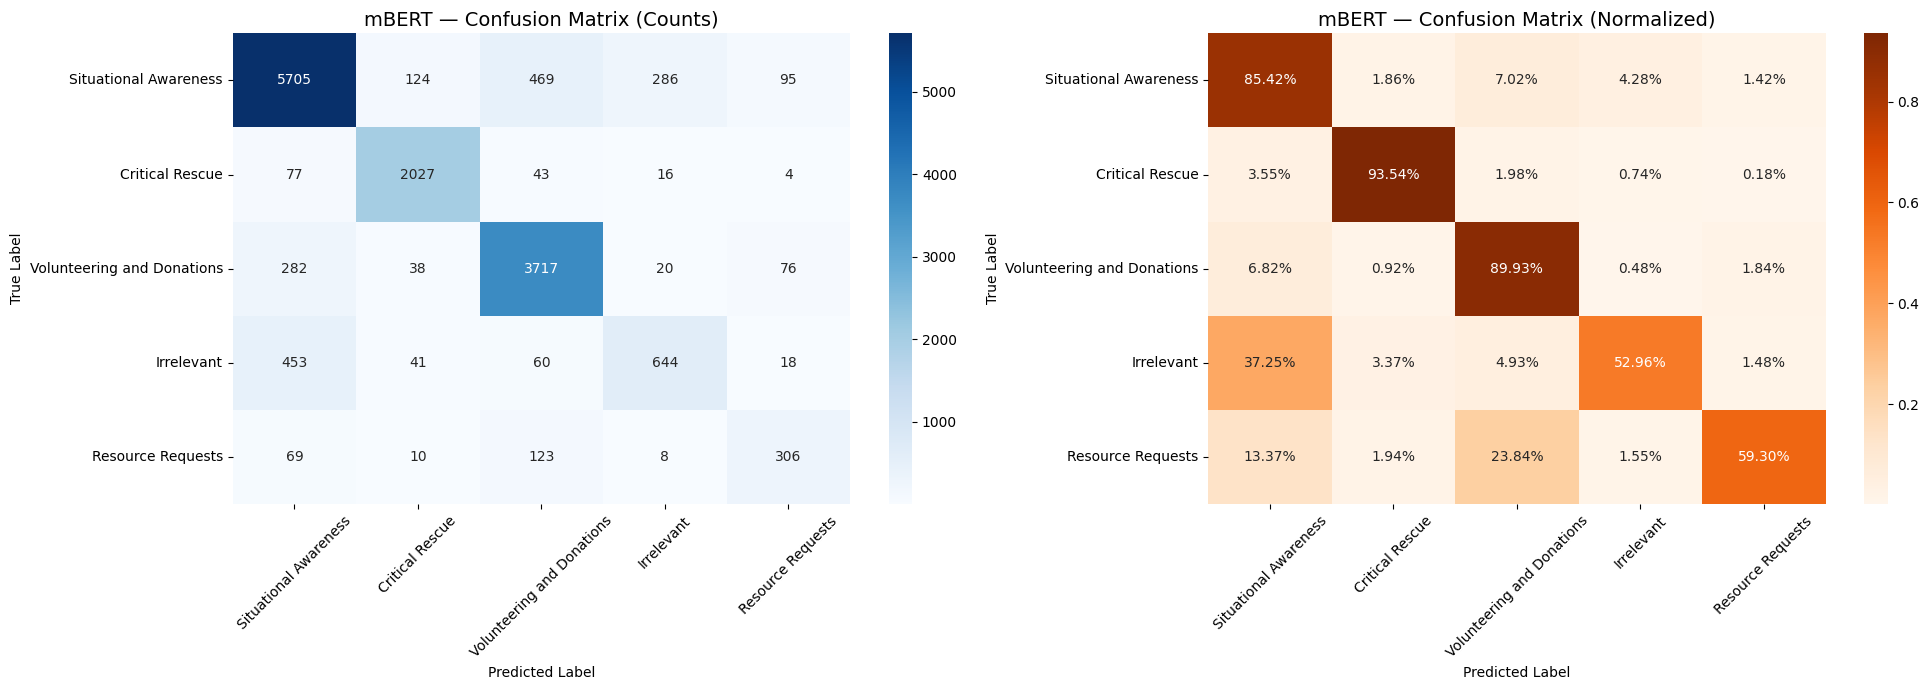

Confusion matrix saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title('mBERT — Confusion Matrix (Counts)', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalized (percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_title('mBERT — Confusion Matrix (Normalized)', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mbert_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

## 10. Save Results

In [ ]:
import json

# Save classification report as JSON (matching project format)
report_dict = classification_report(
    y_true, y_pred,
    target_names=LABEL_NAMES,
    digits=4,
    output_dict=True
)

results_path = os.path.join(OUTPUT_DIR, 'mbert_results.json')
with open(results_path, 'w') as f:
    json.dump(report_dict, f, indent=2)
print(f"Results saved to {results_path}")

# Save error analysis (misclassified samples)
errors_mask = y_pred != y_true
error_df = test_df[errors_mask].copy()
error_df['predicted_label'] = [LABEL_NAMES[p] for p in y_pred[errors_mask]]
error_df['true_label'] = [LABEL_NAMES[t] for t in y_true[errors_mask]]

errors_path = os.path.join(OUTPUT_DIR, 'mbert_errors.csv')
error_df.to_csv(errors_path, index=False)
print(f"Error analysis saved to {errors_path} ({len(error_df)} errors)")

Results saved to /content/results_mbert/mbert_results.json
Error analysis saved to /content/results_mbert/mbert_errors.csv (2312 errors)


## 11. Save Trained Model

In [ ]:
# Save the best model
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
print(f"\n✅ Model saved to {FINAL_MODEL_DIR}")

# List saved files
print("\nSaved files:")
for f in os.listdir(FINAL_MODEL_DIR):
    size = os.path.getsize(os.path.join(FINAL_MODEL_DIR, f))
    print(f"  {f} ({size / 1e6:.1f} MB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved to /content/model_mbert

Saved files:
  training_args.bin (0.0 MB)
  model.safetensors (711.5 MB)
  tokenizer.json (2.9 MB)
  config.json (0.0 MB)
  tokenizer_config.json (0.0 MB)


## 12. Download Results & Model

Run the cells below to download everything to your local machine.

In [ ]:
# Zip the results folder for easy download
!zip -r /content/mbert_results.zip {OUTPUT_DIR}
!zip -r /content/mbert_model.zip {FINAL_MODEL_DIR}

print("\n📦 Files ready for download:")
print(f"  Results: /content/mbert_results.zip")
print(f"  Model:   /content/mbert_model.zip")

  adding: content/results_mbert/ (stored 0%)
  adding: content/results_mbert/mbert_errors.csv (deflated 74%)
  adding: content/results_mbert/mbert_results.json (deflated 61%)
  adding: content/results_mbert/mbert_confusion_matrix.png (deflated 13%)
  adding: content/results_mbert/checkpoint-3248/ (stored 0%)
  adding: content/results_mbert/checkpoint-3248/trainer_state.json (deflated 75%)
  adding: content/results_mbert/checkpoint-3248/scheduler.pt (deflated 61%)
  adding: content/results_mbert/checkpoint-3248/optimizer.pt (deflated 50%)
  adding: content/results_mbert/checkpoint-3248/training_args.bin (deflated 53%)
  adding: content/results_mbert/checkpoint-3248/model.safetensors (deflated 7%)
  adding: content/results_mbert/checkpoint-3248/tokenizer.json (deflated 67%)
  adding: content/results_mbert/checkpoint-3248/config.json (deflated 57%)
  adding: content/results_mbert/checkpoint-3248/tokenizer_config.json (deflated 43%)
  adding: content/results_mbert/checkpoint-3248/scaler.pt

In [ ]:
# Download the zip files
from google.colab import files

print("Downloading results...")
# files.download('/content/mbert_results.zip')

# for downloading the full model
files.download('/content/mbert_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## 📊 Comparison with Baselines

| Model | Accuracy | Weighted F1 | Weighted Precision | Weighted Recall |
|---|---|---|---|---|
| Naive Bayes (TF-IDF) | 0.7379 | 0.7402 | 0.7455 | 0.7379 |
| SVM (TF-IDF) | 0.7970 | 0.7962 | 0.7959 | 0.7970 |
| **mBERT** | *Run this notebook* | *Run this notebook* | *Run this notebook* | *Run this notebook* |

---


In [ ]:
# # Uncomment to save to Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
#
# DRIVE_SAVE = "/content/drive/MyDrive/NLP_PROJECT/model_mbert"
# !cp -r {FINAL_MODEL_DIR} {DRIVE_SAVE}
# !cp -r {OUTPUT_DIR} "/content/drive/MyDrive/NLP_PROJECT/results_mbert"
# print(f"Saved to Google Drive: {DRIVE_SAVE}")